In [1]:
!pip install torch torchvision botorch gpytorch


  Using cached torchvision-0.24.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.9 kB)
  Using cached torch-2.9.1-cp312-none-macosx_11_0_arm64.whl.metadata (30 kB)
Using cached torchvision-0.24.1-cp312-cp312-macosx_11_0_arm64.whl (1.9 MB)
Using cached torch-2.9.1-cp312-none-macosx_11_0_arm64.whl (74.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 29.1 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.8.0
    Uninstalling torch-2.8.0:
      Successfully uninstalled torch-2.8.0

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

# BoTorch / GPyTorch
from botorch.models import SingleTaskGP
from botorch.utils.transforms import normalize, unnormalize
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch import fit_gpytorch_mll
from botorch.optim import optimize_acqf
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
dtype = torch.double  # BoTorch prefers double precision
print("Using device:", device)


Using device: mps


In [11]:
transform = transforms.ToTensor()  # gives float32 in [0,1]

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 60000
Test size: 10000


### Implementing a VAE with Pytorch

We’re going to be implementing a VAE that can generate MNIST digits. It’s going to
have three parts:

1. An _encoder network_ that turns a real image into a mean and a variance in the latent space

2. A _sampling layer_ that takes such a mean and variance, and uses them to sample a random point from the latent space

3. A _decoder network_ that turns points from the latent space back into images

The following listing shows the _encoder network_ we’ll use, mapping images to the
parameters of a probability distribution over the latent space. It’s a simple convnet
that maps the input image `x` to two vectors, `z_mean` and `z_log_var`. One important
detail is that we use strides for downsampling feature maps instead of max pooling -
remember the U-Net in image segmentation. Recall
that, in general, strides are preferable to max pooling for any model that cares about
information location — that is to say, where stuff is in the image — and this one does, since
it will have to produce an image encoding that can be used to reconstruct a valid
image.

In [12]:

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        #  First convolutional layer:
        #   - Input channels: 1 (MNIST grayscale)
        #   - Output channels: 32 filters
        #   - Kernel size: 3×3 filters
        #   - Stride = 2 → downsamples 28×28 → 14×14
        #   - Padding = 1 keeps spatial alignment
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)

        #  Second convolutional layer:
        #   - Input channels: 32 from previous layer
        #   - Output channels: 64 feature maps
        #   - Stride = 2 → downsamples 14×14 → 7×7
        #   - Padding = 1 to preserve spatial size before downsampling
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)

        # • Fully connected layer:
        #   - Input is flattened 7×7×64 tensor = 3136 features
        #   - Output is a compact 16-dimensional hidden representation
        self.fc = nn.Linear(7 * 7 * 64, 16)

        # • Linear layer for mean vector μ of latent distribution
        #   - Output dimension is latent_dim (here = 2)
        self.z_mean = nn.Linear(16, latent_dim)

        # • Linear layer for log-variance log σ²
        #   - Same dimension as z_mean
        #   - Used for reparameterization trick
        self.z_log_var = nn.Linear(16, latent_dim)

    def forward(self, x):
        # • Input x has shape (batch_size, 1, 28, 28)

        # • Apply first convolution + ReLU activation
        x = F.relu(self.conv1(x))

        # • Apply second convolution + ReLU
        x = F.relu(self.conv2(x))

        # • Flatten spatial dimensions (B, 64, 7, 7) → (B, 3136)
        x = x.view(x.size(0), -1)

        # • Apply fully connected hidden layer + ReLU
        h = F.relu(self.fc(x))

        # • Predict mean μ and log-variance log σ²
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)

        # • Return both parameters to generate latent samples
        return z_mean, z_log_var


The following listing shows the decoder implementation. We reshape the vector `z` to
the dimensions of an image and then use a few convolution layers to obtain a final
image output that has the same dimensions as the original `input_img`.

In [13]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # • Fully connected layer mapping latent vector → feature map
        #   - Input: latent_dim (e.g., 2)
        #   - Output: 7 × 7 × 64 feature tensor
        #   - Mirrors the encoder’s final convolutional size
        self.fc = nn.Linear(latent_dim, 7 * 7 * 64)

        # • First transposed convolution (a.k.a. "deconvolution"):
        #   - Input channels: 64
        #   - Output channels: 64
        #   - Kernel size: 3×3 filters
        #   - Stride = 2 → upsampling from 7×7 → 14×14
        #   - Padding = 1, output_padding = 1 ensure exact doubling
        self.deconv1 = nn.ConvTranspose2d(
            64, 64,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

        # • Second transposed convolution:
        #   - Input: 64 channels
        #   - Output: 32 feature maps
        #   - Upsampling from 14×14 → 28×28
        #   - Same kernel/stride/padding pattern
        self.deconv2 = nn.ConvTranspose2d(
            64, 32,
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        )

        # • Final convolution to produce a 1-channel image
        #   - Kernel size: 3×3
        #   - Padding = 1 to keep size 28×28
        #   - Output activation will later squash pixels into [0,1]
        self.conv_out = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, z):
        # • z is a latent vector of shape (B, latent_dim)

        # • Map latent vector to 7×7×64 feature block
        x = F.relu(self.fc(z))

        # • Reshape flat vector into convolutional tensor
        x = x.view(-1, 64, 7, 7)

        # • First upsampling (7 → 14)
        x = F.relu(self.deconv1(x))

        # • Second upsampling (14 → 28)
        x = F.relu(self.deconv2(x))

        # • Final convolution + sigmoid to ensure pixel values in [0,1]
        x = torch.sigmoid(self.conv_out(x))

        # • Output shape: reconstructed image (B, 1, 28, 28)
        return x


Next is the code for using `z_mean` and `z_log_var`, the parameters of the statistical distribution
assumed to have produced `input_img`, to generate a latent space point `z`. Now let’s create the VAE model itself. This is your first example of a model that isn’t
doing supervised learning (an autoencoder is an example of _self-supervised learning_,
because it uses its inputs as targets). Whenever you depart from classic supervised
learning, it’s common to subclass the `Model` class and implement a custom `train_step()` to specify the new training logic. That’s what we’ll do here.

In [14]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # • The VAE consists of two sub-networks:
        #   - Encoder: maps images → latent distribution parameters (μ, log σ²)
        #   - Decoder: maps latent samples → reconstructed images
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        # • Convert log-variance to standard deviation:
        #     std = exp(½ log σ²) = σ
        std = torch.exp(0.5 * logvar)

        # • Sample random noise ε ~ N(0, I) with same shape as std
        eps = torch.randn_like(std)

        # • Reparameterization trick:
        #     z = μ + σ ⊙ ε
        #   Allows gradients to flow through stochastic sampling
        return mu + std * eps

    def forward(self, x):
        # • Encode the input:
        #     mu      → mean vector of latent distribution
        #     logvar  → log-variance (more numerically stable than variance)
        mu, logvar = self.encoder(x)

        # • Sample z using reparameterization trick
        z = self.reparameterize(mu, logvar)

        # • Decode latent vector back into an image
        recon = self.decoder(z)

        # • Return:
        #     - reconstructed image
        #     - mean μ
        #     - log-variance log σ²
        return recon, mu, logvar

    def loss_function(self, recon_x, x, mu, logvar):
        # ============================================================
        # Reconstruction loss (binary cross-entropy)
        # ============================================================
        # • Compute BCE per pixel (reduction='none' keeps all dimensions)
        bce = F.binary_cross_entropy(recon_x, x, reduction='none')

        # • Sum over all pixel dimensions, average over batch
        bce = bce.sum(dim=(1, 2, 3)).mean()
        #   - Encourages recon_x to match x pixel-by-pixel
        #   - Assumes pixel values ∈ [0,1] (hence sigmoid in decoder)

        # ============================================================
        # KL divergence between q(z|x) and N(0, I)
        # ============================================================
        # • Closed-form KL divergence for diagonal Gaussians:
        #     KL = -½ Σ(1 + log σ² − μ² − σ²)
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

        # • Mean over the batch
        kl = kl.mean()

        # ============================================================
        # Total VAE loss = reconstruction + KL
        # ============================================================
        loss = bce + kl

        return loss, bce, kl

Finally, we’re ready to instantiate and train the model on MNIST digits.

In [18]:
def training_VAE(num_epochs = 20, latent_dim=20, lr=1e-3):  # increase for better quality
  vae = VAE(latent_dim=latent_dim).to(device=device, dtype=dtype)
  optimizer = torch.optim.Adam(vae.parameters(), lr)
  for epoch in range(1, num_epochs + 1):
    vae.train()  # • Put VAE into training mode (enables dropout, BN updates)

    # • Accumulators for reporting average losses per epoch
    total_loss = 0.0
    total_bce = 0.0
    total_kl = 0.0
    n_samples = 0  # • Counts total number of processed samples

    # • Iterate over mini-batches from the MNIST DataLoader
    for x, _ in train_loader:
        # • Move batch to GPU/CPU and convert to correct dtype (float64 for BoTorch compatibility)
        x = x.to(device=device, dtype=dtype)  # shape: (B, 1, 28, 28)

        optimizer.zero_grad()  # • Reset gradients from previous iteration

        # • Forward pass through the VAE:
        #   - recon: reconstructed images
        #   - mu, logvar: latent distribution parameters
        recon, mu, logvar = vae(x)

        # • Compute full VAE loss:
        #   - loss = BCE + KL
        #   - bce = reconstruction error
        #   - kl = KL divergence between q(z|x) and N(0, I)
        loss, bce, kl = vae.loss_function(recon, x, mu, logvar)

        # • Backpropagate gradients through encoder+decoder
        loss.backward()

        # • Update model parameters
        optimizer.step()

        # • Track total loss statistics
        bs = x.size(0)              # batch size
        total_loss += loss.item() * bs
        total_bce  += bce.item() * bs
        total_kl   += kl.item() * bs
        n_samples  += bs           # total number of samples seen this epoch

    # • Print epoch summary (averaged over samples)
    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {total_loss / n_samples:.4f} | "
        f"Recon: {total_bce / n_samples:.4f} | "
        f"KL: {total_kl / n_samples:.4f}"
    )
  return vae

Once the model is trained, we can use the decoder network to turn arbitrary latent
space vectors into images.

Epoch 01 | Loss: 210.7923 | Recon: 207.5794 | KL: 3.2129
Epoch 02 | Loss: 169.3459 | Recon: 164.3251 | KL: 5.0208
Epoch 03 | Loss: 164.7807 | Recon: 159.5888 | KL: 5.1919
Epoch 04 | Loss: 162.4720 | Recon: 157.1432 | KL: 5.3288
Epoch 05 | Loss: 161.1324 | Recon: 155.7484 | KL: 5.3840
Epoch 06 | Loss: 160.1819 | Recon: 154.7378 | KL: 5.4441
Epoch 07 | Loss: 159.5523 | Recon: 154.0664 | KL: 5.4859
Epoch 08 | Loss: 158.9602 | Recon: 153.4371 | KL: 5.5230
Epoch 09 | Loss: 158.5157 | Recon: 152.9623 | KL: 5.5534
Epoch 10 | Loss: 158.0969 | Recon: 152.5084 | KL: 5.5885
Epoch 11 | Loss: 157.6790 | Recon: 152.0674 | KL: 5.6115
Epoch 12 | Loss: 157.2676 | Recon: 151.6266 | KL: 5.6409
Epoch 13 | Loss: 156.9932 | Recon: 151.3081 | KL: 5.6851
Epoch 14 | Loss: 156.5903 | Recon: 150.8887 | KL: 5.7016
Epoch 15 | Loss: 156.3680 | Recon: 150.6366 | KL: 5.7314
Epoch 16 | Loss: 156.1137 | Recon: 150.3652 | KL: 5.7485
Epoch 17 | Loss: 155.9132 | Recon: 150.1468 | KL: 5.7664
Epoch 18 | Loss: 155.7580 | Rec

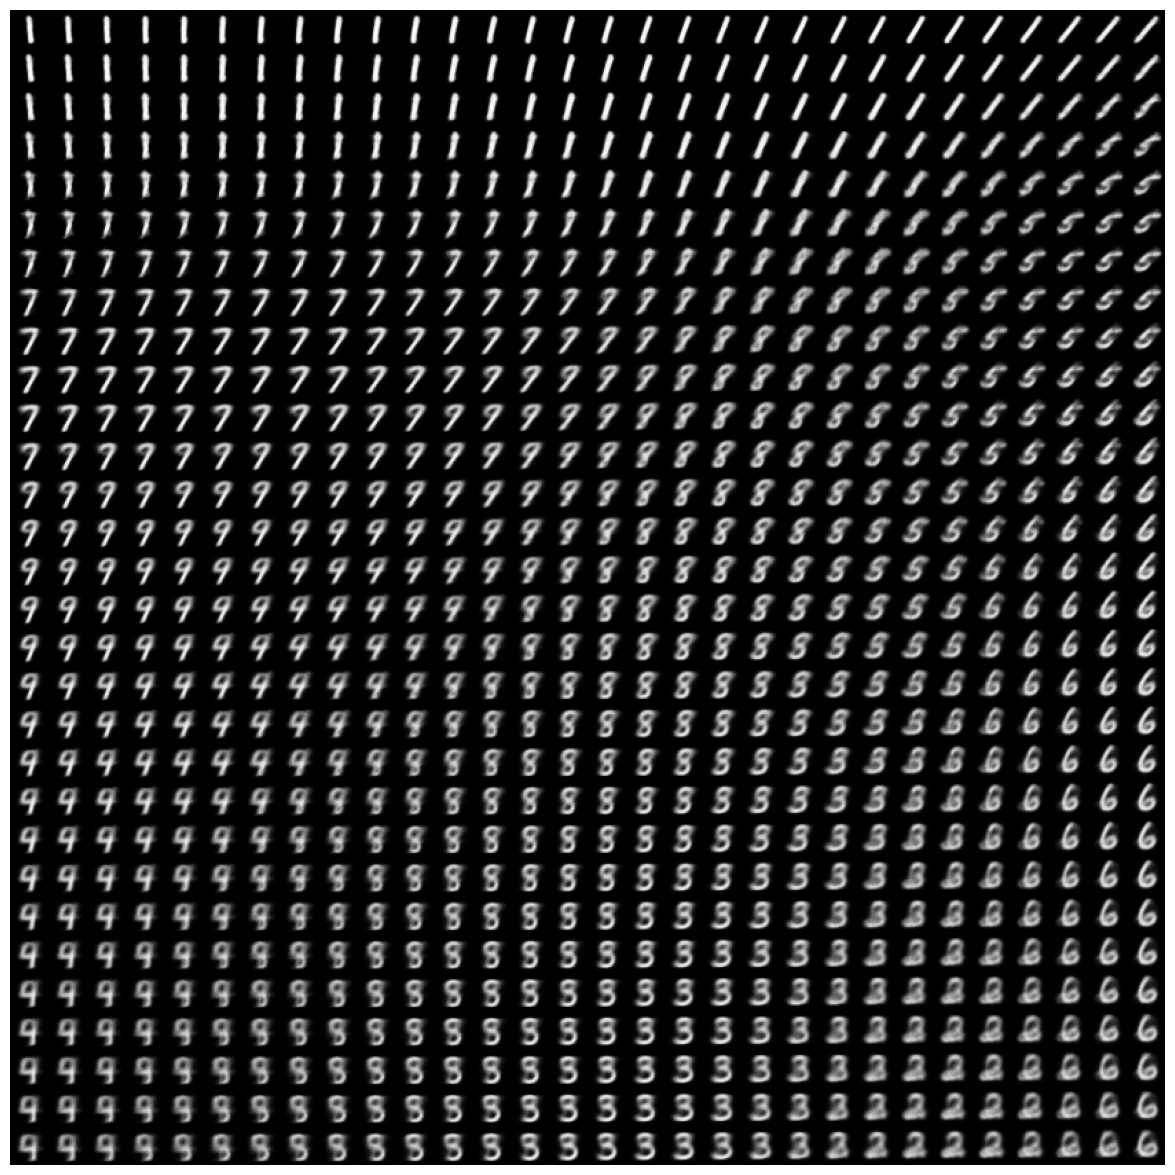

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Make sure the VAE is in eval mode
vae = training_VAE(num_epochs = 20, latent_dim=2,)
vae.eval()

# Number of grid points per axis
n = 30
digit_size = 28

# The big empty canvas to draw 30×30 decoded digits
figure = np.zeros((digit_size * n, digit_size * n))

# Linearly spaced grid in latent space
grid_x = np.linspace(-1, 1, n)
grid_y = np.linspace(-1, 1, n)[::-1]  # reverse Y for visual orientation

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):

        # Create 1×2 latent vector
        z_sample = torch.tensor([[xi, yi]], dtype=dtype, device=device)

        # Decode using the PyTorch VAE
        with torch.no_grad():
            x_decoded = vae.decoder(z_sample)

        # Convert to NumPy
        digit = x_decoded[0].cpu().numpy().reshape(digit_size, digit_size)

        # Place digit image into large canvas
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size
        ] = digit

# Plot nicely
plt.figure(figsize=(15, 15))
start_range = digit_size // 2
end_range = n * digit_size + start_range
pixel_range = np.arange(start_range, end_range, digit_size)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)

plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.axis("off")
plt.imshow(figure, cmap="Greys_r")
plt.show()

The grid of sampled digits (see the figure above) shows a completely continuous distribution
of the different digit classes, with one digit morphing into another as you follow a
path through latent space. Specific directions in this space have a meaning: for example,
there are directions for “five-ness,” “one-ness,” and so on.

## Wrapping up

Wrapping up
- Image generation with deep learning is done by learning latent spaces that capture
statistical information about a dataset of images. By sampling and decoding
points from the latent space, you can generate never-before-seen images.
There are two major tools to do this: VAEs and GANs.

- VAEs result in highly structured, continuous latent representations. For this reason,
they work well for doing all sorts of image editing in latent space: face
swapping, turning a frowning face into a smiling face, and so on. They also work
nicely for doing latent-space-based animations, such as animating a walk along a
cross section of the latent space or showing a starting image slowly morphing
into different images in a continuous way.


# Bayesian Optimization

In this tutorial, we use the MNIST dataset and some standard PyTorch examples to show a synthetic problem where the input to the objective function is a `28 x 28` image. The main idea is to train a [variational auto-encoder (VAE)](https://arxiv.org/abs/1312.6114) on the MNIST dataset and run Bayesian Optimization in the latent space.

## What This Notebook *Actually* Does

- The **VAE is already trained** — we are *not* tuning its hyperparameters.  
- The VAE maps **latent vectors → MNIST images**.  
- A **CNN classifier** scores each generated image by how much it looks like the digit **“3”**.  
- **Bayesian Optimization (BO)** searches the **2D latent space** for vectors that generate images with the **highest classifier score**.

**Objective:**  

$$
\text{latent vector} \;\rightarrow\; \text{image} \;\rightarrow\; \text{classifier score}
$$

This is an **inverse design problem** (“generate an image with a desired property”), not hyperparameter tuning.

---

## Why Use Bayesian Optimization?

BO is well-suited for optimizing over a generative model’s latent space because:

- **Black-box objective:** We do not know how latent changes affect the classifier’s score.  
- **Expensive evaluations:** Each evaluation requires decoding + classification.  
- **Low-dimensional search (2D):** Ideal for Gaussian Process–based BO.  
- **Surrogate modeling:** BO builds a GP of the score function to  
  - explore promising regions,  
  - avoid wasteful sampling,  
  - leverage uncertainty.  
- **Sample efficiency:** BO finds high-scoring latent vectors with *very few* evaluations.

---


In [22]:
vae=training_VAE(latent_dim=20)

Epoch 01 | Loss: 222.7163 | Recon: 217.9197 | KL: 4.7966
Epoch 02 | Loss: 195.6463 | Recon: 191.9787 | KL: 3.6676
Epoch 03 | Loss: 190.8617 | Recon: 187.7833 | KL: 3.0783
Epoch 04 | Loss: 187.7297 | Recon: 184.7513 | KL: 2.9785
Epoch 05 | Loss: 185.3766 | Recon: 182.3743 | KL: 3.0023
Epoch 06 | Loss: 183.5570 | Recon: 180.5003 | KL: 3.0567
Epoch 07 | Loss: 181.9566 | Recon: 178.8687 | KL: 3.0879
Epoch 08 | Loss: 180.6328 | Recon: 177.5257 | KL: 3.1071
Epoch 09 | Loss: 179.6086 | Recon: 176.4628 | KL: 3.1458
Epoch 10 | Loss: 178.7603 | Recon: 175.5893 | KL: 3.1709
Epoch 11 | Loss: 177.8984 | Recon: 174.7010 | KL: 3.1974
Epoch 12 | Loss: 177.2952 | Recon: 174.0429 | KL: 3.2523
Epoch 13 | Loss: 176.6739 | Recon: 173.3970 | KL: 3.2769
Epoch 14 | Loss: 176.1568 | Recon: 172.8324 | KL: 3.3244
Epoch 15 | Loss: 175.8486 | Recon: 172.5079 | KL: 3.3408
Epoch 16 | Loss: 175.4304 | Recon: 172.0543 | KL: 3.3761
Epoch 17 | Loss: 174.9484 | Recon: 171.5549 | KL: 3.3935
Epoch 18 | Loss: 174.7190 | Rec

In [23]:
# Install dependencies if we are running in colab
import sys
if 'google.colab' in sys.modules:
    %pip install botorch

In [24]:
import os
import torch

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets  # transforms

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
dtype = torch.double
SMOKE_TEST = os.environ.get("SMOKE_TEST", False)

### Problem setup

Let's first define our synthetic expensive-to-evaluate objective function. We assume that it takes the following form:

$$\text{image} \longrightarrow \text{image classifier} \longrightarrow \text{scoring function}
\longrightarrow \text{score}.$$

The classifier is a convolutional neural network (CNN) trained using the architecture of the [PyTorch CNN example](https://github.com/pytorch/examples/tree/master/mnist).

In [25]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # First convolutional layer:
        # input channels = 1 (MNIST grayscale)
        # output channels = 20 feature maps
        # kernel size = 5x5
        # stride = 1
        self.conv1 = nn.Conv2d(1, 20, 5, 1)

        # Second convolutional layer:
        # input channels = 20 (from conv1)
        # output channels = 50 feature maps
        # kernel size = 5x5
        # stride = 1
        self.conv2 = nn.Conv2d(20, 50, 5, 1)

        # Fully connected layer:
        # After the two conv + pool operations, the spatial size becomes 4×4
        # and there are 50 feature maps → total features = 4 * 4 * 50
        # This FC layer reduces to 500 hidden units
        self.fc1 = nn.Linear(4 * 4 * 50, 500)

        # Final fully connected layer:
        # 500 → 10 output classes (digits 0–9)
        self.fc2 = nn.Linear(500, 10)


    def forward(self, x):
        # Apply convolution 1 + ReLU activation
        x = F.relu(self.conv1(x))

        # Apply 2×2 max pooling (reduce spatial size by factor 2)
        x = F.max_pool2d(x, 2, 2)

        # Apply convolution 2 + ReLU activation
        x = F.relu(self.conv2(x))

        # Apply 2×2 max pooling again
        x = F.max_pool2d(x, 2, 2)

        # Flatten the tensor into a vector for the fully connected layer
        # (-1 means "infer batch size")
        x = x.view(-1, 4 * 4 * 50)

        # Apply first fully connected layer + ReLU
        x = F.relu(self.fc1(x))

        # Output layer (logits → class scores)
        x = self.fc2(x)

        # Convert logits to log-probabilities using log_softmax
        return F.log_softmax(x, dim=1)

In [26]:
cnn_weights_path = "/content/mnist_cnn.pt"
cnn_model = Net().to(dtype=dtype, device=device)
cnn_state_dict = torch.load(cnn_weights_path, map_location=device, weights_only=True)
cnn_model.load_state_dict(cnn_state_dict);

We now define the __scoring function__ that maps digits to scores. This function is the objective that _Bayesian Optimization_ tries to maximize.

The VAE generates images from latent vectors.
A classifier predicts which digit an image resembles: $y_{\text pred}\in\{0,…,9\}$.

The score function then assigns:

- high score if $y_{\text pred}$ is close to 3

- low score otherwise

BO searches latent space to find images that look increasingly like a “3.”

This makes it a controlled illustration of:

In [27]:
def score(y):
    """
    Returns a score for each digit (0–9).

    The scoring function is a squared-exponential (Gaussian-shaped) function
    centered at the digit '3'. That means:

        - The score is highest when y = 3.
        - The farther y is from 3, the smaller the score becomes.
        - The decay is controlled by the coefficient in the exponential (-2).

    This is an artificial scoring function used to demonstrate Bayesian
    optimization on top of a VAE. It simulates an objective that says:
    'I prefer images that look like the digit 3.'

    Parameters
    ----------
    y : torch.Tensor
        A tensor of predicted digit labels or class indices (e.g., 0–9).

    Returns
    -------
    torch.Tensor
        A score where values near 1 correspond to y ≈ 3 and values approach 0
        as y moves away from 3.
    """

    # Squared exponential function:
    # Computes exp( -2 * (y - 3)^2 )
    # Produces a bell-shaped curve centered at y=3
    return torch.exp(-2 * (y - 3) ** 2)


Given the scoring function, we can now write our overall objective, which as discussed above, starts with an image and outputs a score. Let's say the objective computes the expected score given the probabilities from the classifier.

In [28]:
def score_image(x):
    """
    Takes an input image `x`, passes it through the CNN classifier,
    and returns a scalar score for each image in the batch.

    The score is computed by:
        1. Getting class probabilities from the CNN.
        2. Assigning a "target preference" score to each digit using `score()`.
        3. Taking the expectation of the preference scores under the CNN's predicted probabilities.

    In other words:
        score_image = sum_over_digits [ P(class = d | x) * preference(d) ]

    This creates a smooth, differentiable-like objective for Bayesian optimization
    even though digit classes are discrete.
    """
    # Disable gradient tracking since this is evaluation only
    with torch.no_grad():

        # Pass the image through the trained CNN.
        # cnn_model(x) returns log-probabilities (b × 10) for each digit class.
        # Taking exp() converts them back to actual probabilities.
        probs = torch.exp(cnn_model(x))  # shape: batch_size × 10

        # Compute the target score for each digit 0–9 using the Gaussian centered at 3.
        # torch.arange(10) = [0,1,2,3,4,5,6,7,8,9]
        # score() outputs 10 preference values.
        scores = score(
            torch.arange(10, device=device, dtype=dtype)
        ).expand(probs.shape)  # match shape to batch_size × 10

    # Compute the expected score:
    # Multiply probability of each class by its preference weight,
    # then sum over the digit dimension.
    return (probs * scores).sum(dim=1)


Finally, we define a helper function `decode` that takes as input the parameters `mu` and `logvar` of the variational distribution and performs reparameterization and the decoding. We use batched Bayesian optimization to search over the parameters `mu` and `logvar`

In [29]:
def decode(train_x):
    """
    Decodes latent vectors into images using the VAE decoder.

    Parameters
    ----------
    train_x : torch.Tensor
        A batch of latent vectors from the VAE latent space.
        Shape is typically (batch_size, latent_dim).

    Returns
    -------
    torch.Tensor
        A batch of decoded MNIST images reshaped to
        (batch_size, 1, 28, 28).
    """

    # We do not need gradients because we're not training the VAE here.
    # This speeds up computation and reduces memory usage.
    with torch.no_grad():

        # Pass the latent vectors through the decoder.
        # The decoder maps latent space → reconstructed image in vector form.
        decoded = vae.decoder(train_x)

    # Reshape the decoder output to image format expected by the CNN:
    # batch_size × 1 channel × 28 × 28 pixels.
    return decoded.view(train_x.shape[0], 1, 28, 28)


#### Model initialization and initial random batch

We use a `SingleTaskGP` to model the score of an image generated by a latent representation. The model is initialized with points drawn from $[-6, 6]^{2}$.

In [30]:
from botorch.models import SingleTaskGP
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.utils.transforms import normalize, unnormalize
from botorch.models.transforms import Normalize

# Dimensionality of the latent space we are optimizing over (z ∈ R²)
d = 20

# Bounds of the latent space. BO will only search within [-6, 6] in each dimension.
# Shape: 2 × d → first row = lower bounds, second row = upper bounds.
bounds = torch.tensor([[-6.0] * d, [6.0] * d], device=device, dtype=dtype)


def gen_initial_data(n=5):
    """
    Generate an initial training dataset for Bayesian Optimization.

    This function:
      1. Samples n random latent vectors within the search bounds.
      2. Decodes them into images using the VAE decoder.
      3. Scores the images using the classifier + scoring function.
      4. Returns the training inputs, outputs, and best observed score.
    """

    # Sample n points uniformly from [0,1]^d, then unnormalize them
    # to the actual latent bounds [-6, 6].
    train_x = unnormalize(
        torch.rand(n, d, device=device, dtype=dtype),
        bounds=bounds
    )

    # Evaluate the objective function at these latent points.
    # decode(train_x) → images
    # score_image(image) → scalar objective value
    # unsqueeze(-1) ensures shape is (n, 1), which GP models require.
    train_obj = score_image(decode(train_x)).unsqueeze(-1)

    # Keep track of the best score so far (useful for monitoring BO progress)
    best_observed_value = train_obj.max().item()

    return train_x, train_obj, best_observed_value


def get_fitted_model(train_x, train_obj, state_dict=None):
    """
    Fit a Gaussian Process (GP) surrogate model to observed data.

    Inputs:
      - train_x: latent points explored so far
      - train_obj: corresponding objective values
      - state_dict: optional previous GP state (for warm restarts)

    The GP is trained by maximizing the exact marginal log-likelihood.
    """

    # Initialize a SingleTaskGP model.
    # We normalize the input data to [0,1] using the known bounds,
    # which greatly improves numerical stability.
    model = SingleTaskGP(
        train_X=normalize(train_x, bounds),
        train_Y=train_obj,
    )

    # If we want to continue training from a previous GP state,
    # load the saved parameters.
    if state_dict is not None:
        model.load_state_dict(state_dict)

    # Define the marginal log-likelihood, which GP hyperparameter training optimizes.
    mll = ExactMarginalLogLikelihood(model.likelihood, model)

    # Move MLL to the same device/dtype as training data
    mll.to(train_x)

    # Fit the GP hyperparameters (kernel lengthscale, variance, noise level)
    # using gradient-based optimization under the hood.
    fit_gpytorch_mll(mll)

    return model

#### Define a helper function that performs the essential BO step
The helper function below takes an acquisition function as an argument, optimizes it, and returns the batch $\{x_1, x_2, \ldots x_q\}$ along with the observed function values. For this example, we'll use a small batch of $q=3$.

In [31]:
from botorch.optim import optimize_acqf

# Batch size for qEI/qUCB acquisition optimization.
# q = number of candidates selected per BO iteration.
BATCH_SIZE = 3 if not SMOKE_TEST else 2

# Number of random restarts for acquisition optimization.
# More restarts = better chance of finding a global optimum.
NUM_RESTARTS = 10 if not SMOKE_TEST else 2

# Number of raw candidate samples used for initialization before L-BFGS refinement.
RAW_SAMPLES = 256 if not SMOKE_TEST else 4


def optimize_acqf_and_get_observation(acq_func):
    """
    Optimize the acquisition function to propose new latent points
    and evaluate their objective values.

    Steps:
      1. Optimize acquisition function (e.g., qEI) over normalized bounds [0,1]^d.
      2. Unnormalize candidates back to actual latent-space bounds [-6, 6].
      3. Decode latent points → images.
      4. Score the images using classifier + scoring function.
      5. Return new training inputs (new_x) and observations (new_obj).
    """

    # ---- 1. Optimize the acquisition function ----
    # optimize_acqf returns q new candidate points in [0,1]^d space.
    candidates, _ = optimize_acqf(
        acq_function=acq_func,
        bounds=torch.stack(
            [
                torch.zeros(d, dtype=dtype, device=device),  # lower bound of [0,1]^d
                torch.ones(d, dtype=dtype, device=device),   # upper bound of [0,1]^d
            ]
        ),
        q=BATCH_SIZE,              # number of candidates to suggest at once
        num_restarts=NUM_RESTARTS, # multi-start optimization to avoid local optima
        raw_samples=RAW_SAMPLES,   # number of random initial points
    )

    # ---- 2. Convert normalized candidates back to actual latent bounds ----
    # candidates are in [0,1]; unnormalize maps them into [-6, 6].
    new_x = unnormalize(candidates.detach(), bounds=bounds)

    # ---- 3. Evaluate the objective function ----
    # Score the decoded images.
    # unsqueeze(-1) ensures shape (batch_size, 1) for GP compatibility.
    new_obj = score_image(decode(new_x)).unsqueeze(-1)

    return new_x, new_obj


### Perform Bayesian Optimization loop with qEI
The Bayesian optimization "loop" for a batch size of $q$ simply iterates the following steps: (1) given a surrogate model, choose a batch of points $\{x_1, x_2, \ldots x_q\}$, (2) observe $f(x)$ for each $x$ in the batch, and (3) update the surrogate model. We run `N_BATCH=75` iterations. The acquisition function is approximated using `MC_SAMPLES=2048` samples. We also initialize the model with 5 randomly drawn points.

In [32]:
from botorch import fit_gpytorch_mll
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler

# Set random seed for reproducibility of BO results
seed = 1
torch.manual_seed(seed)

# Number of Bayesian optimization iterations (batches) to run.
# This controls how many times BO proposes new candidates.
N_BATCH = 25 if not SMOKE_TEST else 3

# This list will store the best objective value seen so far after each iteration.
best_observed = []

# ---------------------------------------------------------------
# 1. Generate an initial dataset of latent vectors and scores
# ---------------------------------------------------------------
# gen_initial_data:
#   - randomly samples initial latent points
#   - decodes them into images
#   - scores them using the classifier + scoring function
#   - returns (train_x, train_obj, best_value)
train_x, train_obj, best_value = gen_initial_data(n=5)

# Record the best initial objective value
best_observed.append(best_value)


We are now ready to run the BO loop (this make take a few minutes, depending on your machine).

In [33]:
import warnings
from matplotlib import pyplot as plt

# Suppress warnings for cleaner output (e.g., GP convergence warnings)
warnings.filterwarnings("ignore")


print(f"\nRunning BO ", end="")

# This will store the GP model parameters between iterations (warm-starting)
state_dict = None

# ---------------------------------------------------------------
# Run N_BATCH rounds of Bayesian Optimization
# ---------------------------------------------------------------
for iteration in range(N_BATCH):

    # -----------------------------------------------------------
    # 1. Fit (or refit) the Gaussian Process surrogate model
    # -----------------------------------------------------------
    # get_fitted_model:
    #   - normalizes inputs
    #   - fits GP hyperparameters
    #   - optionally loads previous state_dict to warm-start
    model = get_fitted_model(
        train_x=train_x,
        train_obj=train_obj,
        state_dict=state_dict,
    )

    # -----------------------------------------------------------
    # 2. Define the acquisition function: q-Expected Improvement
    # -----------------------------------------------------------
    # qEI encourages sampling points that have high *expected* improvement
    # over the current best observed objective value.
    qEI = qExpectedImprovement(
        model=model,
        best_f=train_obj.max(),  # current best objective value
    )

    # -----------------------------------------------------------
    # 3. Optimize the acquisition function to get new BO samples
    # -----------------------------------------------------------
    # optimize_acqf_and_get_observation:
    #   - optimizes qEI in normalized space [0,1]^d
    #   - unnormalizes to latent space
    #   - decodes latent → image → score
    new_x, new_obj = optimize_acqf_and_get_observation(qEI)

    # -----------------------------------------------------------
    # 4. Update the training dataset with newly observed data
    # -----------------------------------------------------------
    train_x = torch.cat((train_x, new_x))     # append new latent points
    train_obj = torch.cat((train_obj, new_obj))  # append new scores

    # -----------------------------------------------------------
    # 5. Track optimization progress
    # -----------------------------------------------------------
    best_value = train_obj.max().item()  # best score so far
    best_observed.append(best_value)     # record for plotting later

    # Save the current GP state to warm-start training next iteration
    state_dict = model.state_dict()

    # Print progress indicator (a dot) for each BO iteration
    print(".", end="")


Running BO .........................

EI recommends the best point observed so far. We can visualize what the images corresponding to recommended points *would have* been if the BO process ended at various times. Here, we show the progress of the algorithm by examining the images at 0%, 10%, 25%, 50%, 75%, and 100% completion. The first image is the best image found through the initial random batch.

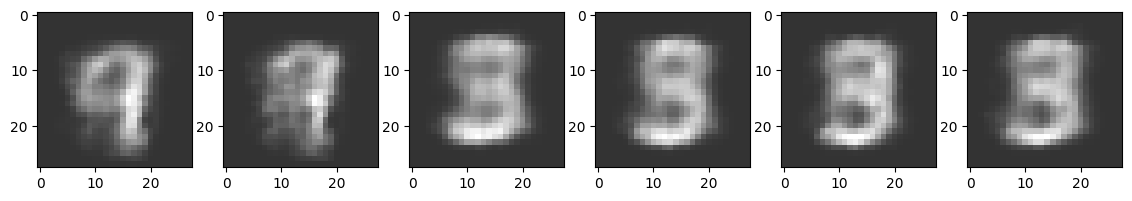

In [34]:
import numpy as np
from matplotlib import pyplot as plt

# Enable inline plotting in Jupyter notebooks
%matplotlib inline


# ---------------------------------------------------------------
# Create a figure with 1 row and 6 columns of subplots
# ---------------------------------------------------------------
fig, ax = plt.subplots(1, 6, figsize=(14, 14))

# Percentages of the BO run at which we want to visualize the best image
percentages = np.array([0, 10, 25, 50, 75, 100], dtype=np.float32)

# Convert percentages into dataset indices.
# Explanation:
#   - N_BATCH * BATCH_SIZE = total number of evaluated points during BO
#   - multiply by percent to find progress point
#   - +4 accounts for the initial 5 random samples (indices 0–4)
inds = (N_BATCH * BATCH_SIZE * percentages / 100 + 4).astype(int)


# ---------------------------------------------------------------
# Loop over the 6 subplot locations
# Each subplot displays the *best-scoring image* up to that stage
# ---------------------------------------------------------------
for i, ax in enumerate(ax.flat):

    # -----------------------------------------------------------
    # Find index of the image with the highest score among the
    # points observed up to the percentage threshold "inds[i]"
    # -----------------------------------------------------------
    # score_image(decode(...)) → scores for each latent vector
    # torch.argmax(..., dim=0) → selects the index of the best one
    b = torch.argmax(score_image(decode(train_x[: inds[i], :])), dim=0)

    # -----------------------------------------------------------
    # Decode the corresponding latent vector into an image
    # reshape from vector back to image shape
    # squeeze() removes channel/extra dims
    # cpu() moves tensor to CPU for plotting
    # -----------------------------------------------------------
    img = decode(train_x[b].view(1, -1)).squeeze().cpu()

    # -----------------------------------------------------------
    # Display the image
    # alpha=0.8 gives slight transparency
    # cmap="gray" is appropriate for MNIST images
    # -----------------------------------------------------------
    ax.imshow(img, alpha=0.8, cmap="gray")


We also refer readers to [this tutorial](http://krasserm.github.io/2018/04/07/latent-space-optimization/), which discusses [the method](https://arxiv.org/abs/1610.02415) of jointly training a VAE with a predictor (e.g., classifier), and shows a similar tutorial for the MNIST setting.